In [102]:
import time
from pathlib import Path

import pandas as pd 
import numpy as np


from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

import seaborn as sns
import matplotlib.pyplot as plt

In [103]:
FOLDER = Path.cwd().parent
DATA_RUTE = FOLDER / 'Data'

historico_equipos = pd.read_csv(DATA_RUTE / 'historico_equipos.csv', index_col=[0], parse_dates=[0])
historico_equipos.sort_index(inplace=True)

data_x = pd.read_csv(DATA_RUTE / 'X.csv', index_col=[0], parse_dates=[0])
data_x.sort_index(inplace=True)

# Warning por errores en el formato del csv
data_y = pd.read_csv(DATA_RUTE / 'Y.csv', index_col=[0], parse_dates=[0], dayfirst=True, sep=';', decimal=',')
data_y.sort_index(inplace=True)

# Las columnas estan invertidas
data_z = pd.read_csv(DATA_RUTE / 'Z.csv', index_col='Date', parse_dates=['Date'])
data_z.sort_index(inplace=True)

print('El indice es creciente:',historico_equipos.index.is_monotonic_increasing, '\n')

print('Tamaños de los Datasets: Filas/Columnas')
print(historico_equipos.shape, data_x.shape, data_y.shape, data_z.shape)

El indice es creciente: True 

Tamaños de los Datasets: Filas/Columnas
(3530, 5) (9144, 1) (4485, 1) (3565, 1)


In [104]:
historico_equipos.columns

Index(['Price_X', 'Price_Y', 'Price_Z', 'Price_Equipo1', 'Price_Equipo2'], dtype='str')

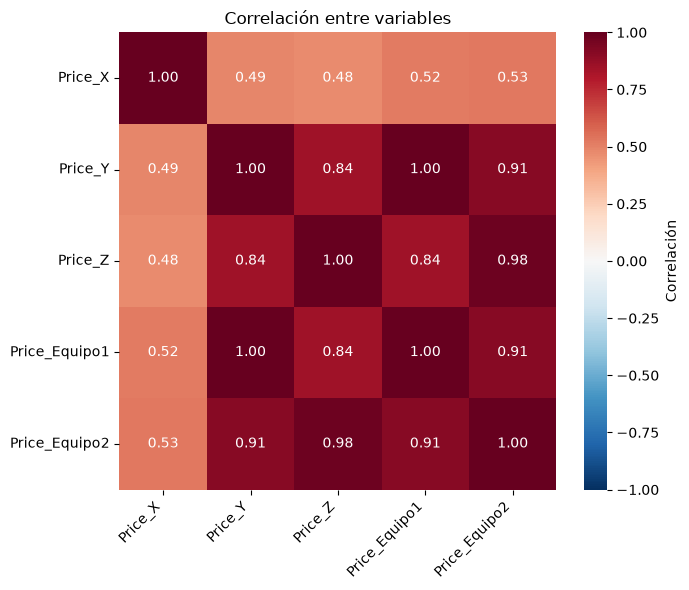

In [105]:
# Matriz de correlaciones 

cols_corr = ['Price_X', 'Price_Y', 'Price_Z', 'Price_Equipo1', 'Price_Equipo2']

corr = historico_equipos[cols_corr].astype(float).corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, cbar_kws={'label': 'Correlación'}, annot_kws={'size': 10})

ax.set_title('Correlación entre variables')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
fig.tight_layout()
plt.show()


In [106]:
data_equipo1 = historico_equipos.drop(columns=['Price_X', 'Price_Equipo1', 'Price_Equipo2'])

In [107]:
data_equipo1.tail()

,Price_Y,Price_Z
Date,,
2023-08-25,554.00,2123.50
2023-08-28,549.00,2116.25
2023-08-29,545.33,2116.25
2023-08-30,543.67,2140.25
2023-08-31,545.00,2165.25


In [111]:
def make_features(data, max_lag, rolling_mean_size):
    data['year'] = data.index.year
    data['month'] = data.index.month
    data['day'] = data.index.day
    data['dayofweek'] = data.index.dayofweek
    for lag in range(1, max_lag + 1):
        data['lag_{}'.format(lag)] = data['Price_Y'].shift(lag)
    data['rolling_mean'] = (
        data['Price_Y'].shift().rolling(rolling_mean_size).mean()
    )

make_features(data_equipo1, 7, 20)

data_equipo1.tail(20)

,Price_Y,Price_Z,year,month,day,dayofweek,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,rolling_mean
Date,,,,,,,,,,,,,,
2023-08-04,568.33,2165.00,2023,8,4,4,564.00,570.00,575.00,575.00,575.00,575.00,575.00,559.0080
2023-08-07,568.33,2177.75,2023,8,7,0,568.33,564.00,570.00,575.00,575.00,575.00,575.00,560.2910
2023-08-08,568.33,2142.50,2023,8,8,1,568.33,568.33,564.00,570.00,575.00,575.00,575.00,561.7740
2023-08-09,565.00,2152.50,2023,8,9,2,568.33,568.33,568.33,564.00,570.00,575.00,575.00,563.1070
2023-08-10,561.67,2161.25,2023,8,10,3,565.00,568.33,568.33,568.33,564.00,570.00,575.00,564.2325
2023-08-11,560.00,2126.00,2023,8,11,4,561.67,565.00,568.33,568.33,568.33,564.00,570.00,564.8785
2023-08-14,555.00,2095.75,2023,8,14,0,560.00,561.67,565.00,568.33,568.33,568.33,564.00,564.9620
2023-08-15,555.00,2085.25,2023,8,15,1,555.00,560.00,561.67,565.00,568.33,568.33,568.33,565.1285
2023-08-16,555.00,2088.75,2023,8,16,2,555.00,555.00,560.00,561.67,565.00,568.33,568.33,565.2120


In [112]:
data_equipo1.tail(20)

,Price_Y,Price_Z,year,month,day,dayofweek,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,rolling_mean
Date,,,,,,,,,,,,,,
2023-08-04,568.33,2165.00,2023,8,4,4,564.00,570.00,575.00,575.00,575.00,575.00,575.00,559.0080
2023-08-07,568.33,2177.75,2023,8,7,0,568.33,564.00,570.00,575.00,575.00,575.00,575.00,560.2910
2023-08-08,568.33,2142.50,2023,8,8,1,568.33,568.33,564.00,570.00,575.00,575.00,575.00,561.7740
2023-08-09,565.00,2152.50,2023,8,9,2,568.33,568.33,568.33,564.00,570.00,575.00,575.00,563.1070
2023-08-10,561.67,2161.25,2023,8,10,3,565.00,568.33,568.33,568.33,564.00,570.00,575.00,564.2325
2023-08-11,560.00,2126.00,2023,8,11,4,561.67,565.00,568.33,568.33,568.33,564.00,570.00,564.8785
2023-08-14,555.00,2095.75,2023,8,14,0,560.00,561.67,565.00,568.33,568.33,568.33,564.00,564.9620
2023-08-15,555.00,2085.25,2023,8,15,1,555.00,560.00,561.67,565.00,568.33,568.33,568.33,565.1285
2023-08-16,555.00,2088.75,2023,8,16,2,555.00,555.00,560.00,561.67,565.00,568.33,568.33,565.2120


In [110]:
train, test = train_test_split(data_equipo1)